In [1]:
import os

# Pull in repository as needed
if os.path.exists('/content/AAI-551-Final-Project'):
    os.chdir('/content/AAI-551-Final-Project')
    !git pull origin main
    print("Updated to latest version from GitHub")
else:
    os.chdir('/content')
    !git clone https://github.com/zreece-sit/AAI-551-Final-Project.git
    os.chdir('/content/AAI-551-Final-Project')
    print("Cloned fresh copy from GitHub")

# Add to Python path
import sys
sys.path.insert(0, '/content/AAI-551-Final-Project')

print(f"Current directory: {os.getcwd()}")
print("Ready to run!")

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 930 bytes | 232.00 KiB/s, done.
From https://github.com/zreece-sit/AAI-551-Final-Project
 * branch            main       -> FETCH_HEAD
   bb55e4e..9835a3f  main       -> origin/main
Updating bb55e4e..9835a3f
Fast-forward
 README.md | 12 ------------
 1 file changed, 12 deletions(-)
Updated to latest version from GitHub
Current directory: /content/AAI-551-Final-Project
Ready to run!


In [2]:
# Install all requirements
!pip install -r requirements.txt

In [3]:
# Standard library imports
import os
import sys

# Add src to path
sys.path.append(os.path.join(os.getcwd(), 'src'))

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local imports
from src.data_loader import DataLoader
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer, calculate_top_k_accuracy
from src.predictor import MusicPredictor
from src.visualizer import Visualizer

print("All modules imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All modules imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2


In [4]:
"""Configuration parameters for the pipeline."""

# Directories
RAW_DATA_DIR = "data/raw/"
PROCESSED_DATA_DIR = "data/processed/"
MODEL_DIR = "models/"
ARTIFACTS_DIR = "artifacts/"

# Data processing parameters
GENRE_THRESHOLD = 1000  # Minimum tag occurrences to be considered a genre
TOP_N_ARTISTS = 20      # Number of top artists per user to consider

# Model parameters
HIDDEN_LAYERS = [256, 128, 64]
DROPOUT_RATES = [0.3, 0.2, 0.1]
EPOCHS = 50
BATCH_SIZE = 64
RANDOM_STATE = 42

# Paths
MODEL_PATH = os.path.join(MODEL_DIR, "multilabel_model.h5")

print("Configuration set!")
print(f"Model will be saved to: {MODEL_PATH}")

Configuration set!
Model will be saved to: models/multilabel_model.h5


In [5]:
"""
Download and load the Last.fm dataset
"""

# Initialize data loader
loader = DataLoader(raw_dir=RAW_DATA_DIR)

# Download and extract dataset
try:
    loader.download_dataset()
    loader.extract_dataset()
    print("\nDataset downloaded and extracted successfully!")
except Exception as e:
    print(f"Error during data loading: {e}")
    print("Please check your internet connection and try again.")
    raise

# Load raw data files
try:
    user_artists, demographics, artists, user_tags, tags = loader.load_raw_data()
    print("Data loaded successfully!")
    print(f"User artists shape: {user_artists.shape}")
    print(f"Demographics shape: {demographics.shape}")
    print(f"Artists shape: {artists.shape}")
    print(f"User tags shape: {user_tags.shape}")
    print(f"Tags shape: {tags.shape}")
except Exception as e:
    print(f"Error loading data files: {e}")
    raise

# Quick data exploration
print("\nUser Artists Sample:")
print(user_artists.head())
print("\nDemographics Sample:")
print(demographics.head())

Dataset already downloaded.
Extracting dataset...
Extraction complete!

Dataset downloaded and extracted successfully!
Loaded user_artists: (92834, 3)
Loaded demographics: (992, 5)
Loaded artists: (17632, 4)
Loaded user_tags: (186479, 6)
Loaded tags: (11946, 2)
Data loaded successfully!
User artists shape: (92834, 3)
Demographics shape: (992, 5)
Artists shape: (17632, 4)
User tags shape: (186479, 6)
Tags shape: (11946, 2)

User Artists Sample:
   userID  artistID  weight
0       2        51   13883
1       2        52   11690
2       2        53   11351
3       2        54   10300
4       2        55    8983

Demographics Sample:
           #id gender   age        country    registered
0  user_000001      m   NaN          Japan  Aug 13, 2006
1  user_000002      f   NaN           Peru  Feb 24, 2006
2  user_000003      m  22.0  United States  Oct 30, 2005
3  user_000004      f   NaN            NaN  Apr 26, 2006
4  user_000005      m   NaN       Bulgaria  Jun 29, 2006


In [6]:
"""
Process data and extract genre information
"""

# Initialize processor (inherits from DataLoader)
processor = DataProcessor(
    raw_dir=RAW_DATA_DIR,
    processed_dir=PROCESSED_DATA_DIR,
    genre_threshold=GENRE_THRESHOLD,
    top_n_artists=TOP_N_ARTISTS
)

# Extract genres from tags
print("\n1. Extracting genre information...")
artist_tags_df = processor.extract_genres(tags, user_tags)
print(f"Artist tags extracted: {artist_tags_df.shape}")

# Filter to common genres
print("\n2. Filtering common genres...")
common_genres = processor.filter_common_genres(artist_tags_df)
print(f"Found {len(common_genres)} common genres")
print(f"Sample genres: {common_genres[:10]}")

# Process user-genre relationships
print("\n3. Processing user-genre relationships...")
user_genre_multi = processor.process_user_genres(
    user_artists,
    artist_tags_df,
    common_genres
)
print(f"User-genre relationships: {user_genre_multi.shape}")

# Prepare features and labels
print("\n4. Preparing features and labels...")
X, Y, genre_classes = processor.prepare_features_and_labels(
    user_genre_multi,
    demographics
)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label matrix shape: {Y.shape}")
print(f"Number of genres: {len(genre_classes)}")
print(f"Genre classes: {genre_classes}")

# Save processed data
print("\n5. Saving processed data...")
processor.save_processed_data(X, Y, genre_classes)
print("Processed data saved successfully!")


1. Extracting genre information...
Artist tags extracted: (12523, 2)

2. Filtering common genres...
Found 7 common genres (threshold: 1000)
Found 7 common genres
Sample genres: ['seen live', 'electronic', 'rock', 'alternative', 'indie', 'pop', 'female vocalists']

3. Processing user-genre relationships...
Processed 1879 users with genre preferences
User-genre relationships: (1879, 2)

4. Preparing features and labels...
Final dataset shape: (905, 6)

Feature matrix shape: (905, 658)
Label matrix shape: (905, 7)
Number of genres: 7
Genre classes: ['alternative', 'electronic', 'female vocalists', 'indie', 'pop', 'rock', 'seen live']

5. Saving processed data...
Processed data and artifacts saved successfully!
Processed data saved successfully!


In [7]:
"""
Build and train the neural network model
"""

from sklearn.decomposition import PCA

# Reduce dimensions for better accuracy
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X = pca.fit_transform(X)

# Initialize model trainer
trainer = ModelTrainer(input_dim=X.shape[1], output_dim=Y.shape[1])

# Build model
print("1. Building model...")
trainer.build_model(hidden_layers=HIDDEN_LAYERS, dropout_rates=DROPOUT_RATES)
trainer.summary()

# Train model
print("2. Training model...")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")

data_splits = trainer.train(
    X, Y,
    test_size=0.3,
    val_size=0.5,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    model_save_path=MODEL_PATH,
    random_state=RANDOM_STATE
)

print("Model training complete!")

# Extract splits for evaluation
X_train = data_splits['X_train']
y_train = data_splits['y_train']
X_val = data_splits['X_val']
y_val = data_splits['y_val']
X_test = data_splits['X_test']
y_test = data_splits['y_test']

1. Building model...
Model built successfully!
Input dimension: 466
Output dimension: 7


Model: "genre_predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 466)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       119,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,159 (629.53 KB)

 Trainable params: 161,159 (629.53 KB)

 Non-trainable params: 0 (0.00 B)

2. Training model...
Epochs: 50
Batch size: 64
Train shape: (633, 466)
Validation shape: (136, 466)
Test shape: (136, 466)

Starting training...
Epoch 1/50
10/10 - 3s - 285ms/step - accuracy: 0.0869 - loss: 0.6570 - val_accuracy: 0.1471 - val_loss: 0.5917
Epoch 2/50
10/10 - 0s - 25ms/step - accuracy: 0.3839 - loss: 0.5076 - val_accuracy: 0.9412 - val_loss: 0.3823
Epoch 3/50
10/10 - 0s - 24ms/step - accuracy: 0.6856 - loss: 0.3050 - val_accuracy: 0.9779 - val_loss: 0.2511
Epoch 4/50
10/10 - 0s - 31ms/step - accuracy: 0.7030 - loss: 0.2576 - val_accuracy: 0.9779 - val_loss: 0.2492
Epoch 5/50
10/10 - 0s - 25ms/step - accuracy: 0.6003 - loss: 0.2398 - val_accuracy: 0.7279 - val_loss: 0.2407
Epoch 6/50
10/10 - 0s - 26ms/step - accuracy: 0.4360 - loss: 0.2228 - val_accuracy: 0.1985 - val_loss: 0.2363
Epoch 7/50
10/10 - 0s - 30ms/step - accuracy: 0.3112 - loss: 0.2143 - val_accuracy: 0.2794 - val_loss: 0.2357
Epoch 8/50
10/10 - 0s - 22ms/step - accuracy: 0.3412 - loss: 0.2034 - val_accuracy: 

1. Evaluating on test set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Test Set Evaluation:
hamming_loss: 0.0851
micro_f1: 0.9556
macro_f1: 0.9538
2. Calculating top-k accuracies...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Top-1 accuracy: 0.9706
Top-3 accuracy: 1.0000
Top-5 accuracy: 1.0000
3. Visualizing training history...


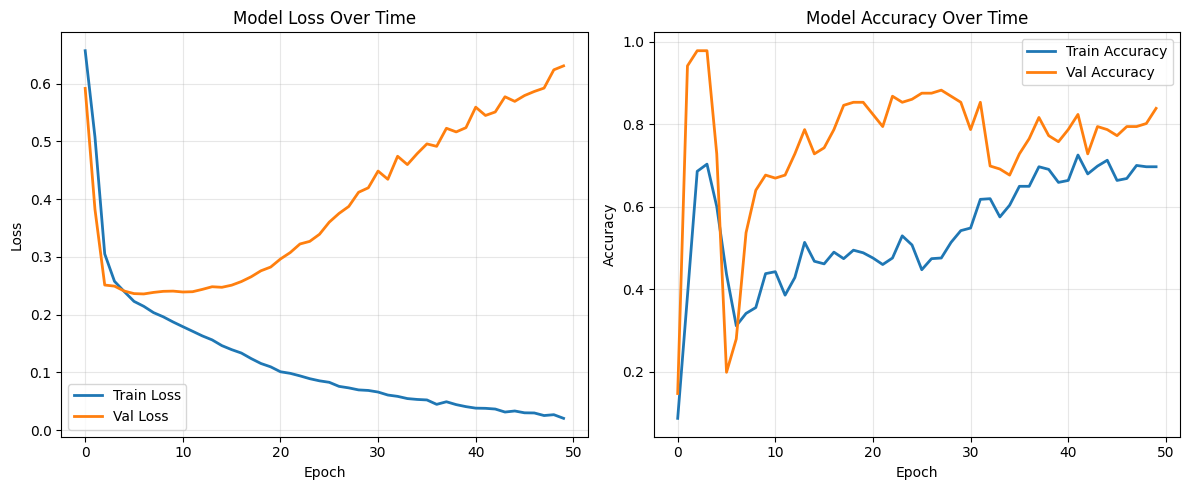

In [8]:
"""
Evaluate model performance
"""

# Evaluate on test set
print("1. Evaluating on test set...")
metrics = trainer.evaluate(X_test, y_test)

# Calculate top-k accuracies
print("2. Calculating top-k accuracies...")
y_prob_test = trainer.model.predict(X_test)

for k in [1, 3, 5]:
    acc = calculate_top_k_accuracy(y_test, y_prob_test, k=k)
    print(f"Top-{k} accuracy: {acc:.4f}")

# Visualize training history
print("3. Visualizing training history...")
visualizer = Visualizer(predictor=None)  # Will set predictor later
visualizer.plot_training_history(trainer.history, figsize=(12, 5))

In [9]:
"""
Make predictions for new users
"""

# Load predictor
print("1. Loading predictor...")
predictor = MusicPredictor.load_model(MODEL_PATH, ARTIFACTS_DIR)

# Update visualizer with predictor
visualizer = Visualizer(predictor)

# Example users for prediction
example_users = [
    {
        'name': 'Young Male US User',
        'data': {'age': 23, 'gender': 'm', 'country': 'United States', 'registered': 2010}
    },
    {
        'name': 'Older Female UK User',
        'data': {'age': 45, 'gender': 'f', 'country': 'United Kingdom', 'registered': 2008}
    },
    {
        'name': 'Middle-aged User from Germany',
        'data': {'age': 35, 'gender': 'm', 'country': 'Germany', 'registered': 2011}
    }
]

# Make predictions for each user
print("2. Predicting genres for example users...")

for user_info in example_users:
    print(f"{user_info['name']}:")
    print(f"Demographics: {user_info['data']}")
    print("Top-5 Predicted Genres:")

    predictions = predictor.predict(user_info['data'], top_k=5)

    # Use enumerate to display results
    for i, (genre, prob) in enumerate(predictions, 1):
        print(f"  {i}. {genre}: {prob:.3f}")

    print()

1. Loading predictor...
MusicPredictor loaded successfully!
Model expects 658 features
Predicts 7 genres
2. Predicting genres for example users...
Young Male US User:
Demographics: {'age': 23, 'gender': 'm', 'country': 'United States', 'registered': 2010}
Top-5 Predicted Genres:


/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]
/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]


  1. rock: 0.960
  2. seen live: 0.956
  3. alternative: 0.951
  4. pop: 0.907
  5. electronic: 0.899

Older Female UK User:
Demographics: {'age': 45, 'gender': 'f', 'country': 'United Kingdom', 'registered': 2008}
Top-5 Predicted Genres:
  1. rock: 0.990
  2. seen live: 0.988
  3. alternative: 0.985
  4. indie: 0.954
  5. pop: 0.951

Middle-aged User from Germany:
Demographics: {'age': 35, 'gender': 'm', 'country': 'Germany', 'registered': 2011}
Top-5 Predicted Genres:


/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]
/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]
/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]


  1. rock: 0.972
  2. seen live: 0.965
  3. alternative: 0.959
  4. pop: 0.913
  5. indie: 0.908



Visualizing predictions for: Young Male US User


/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]
/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]


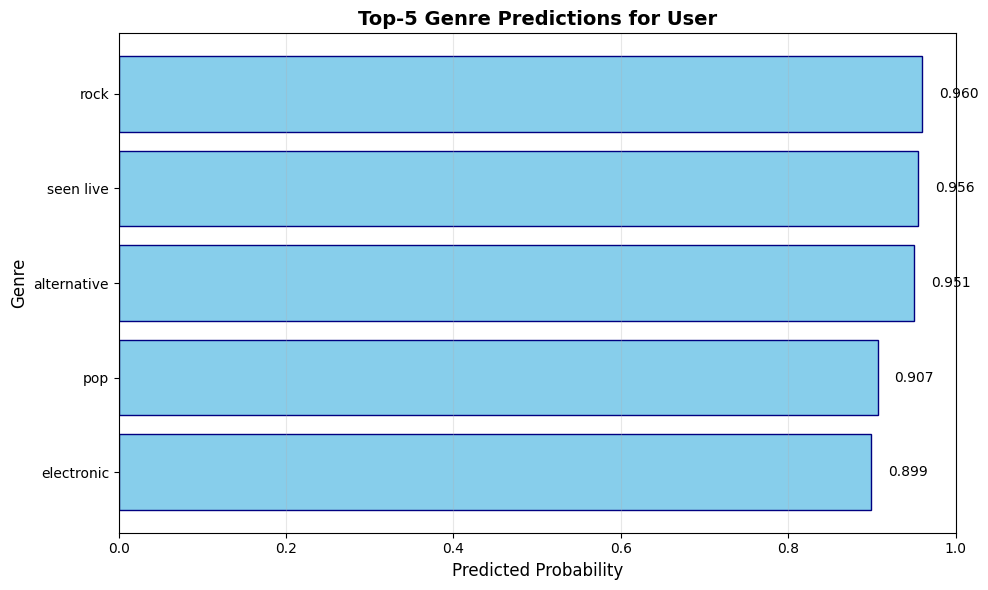

Showing all genre probabilities...


/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]
/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]


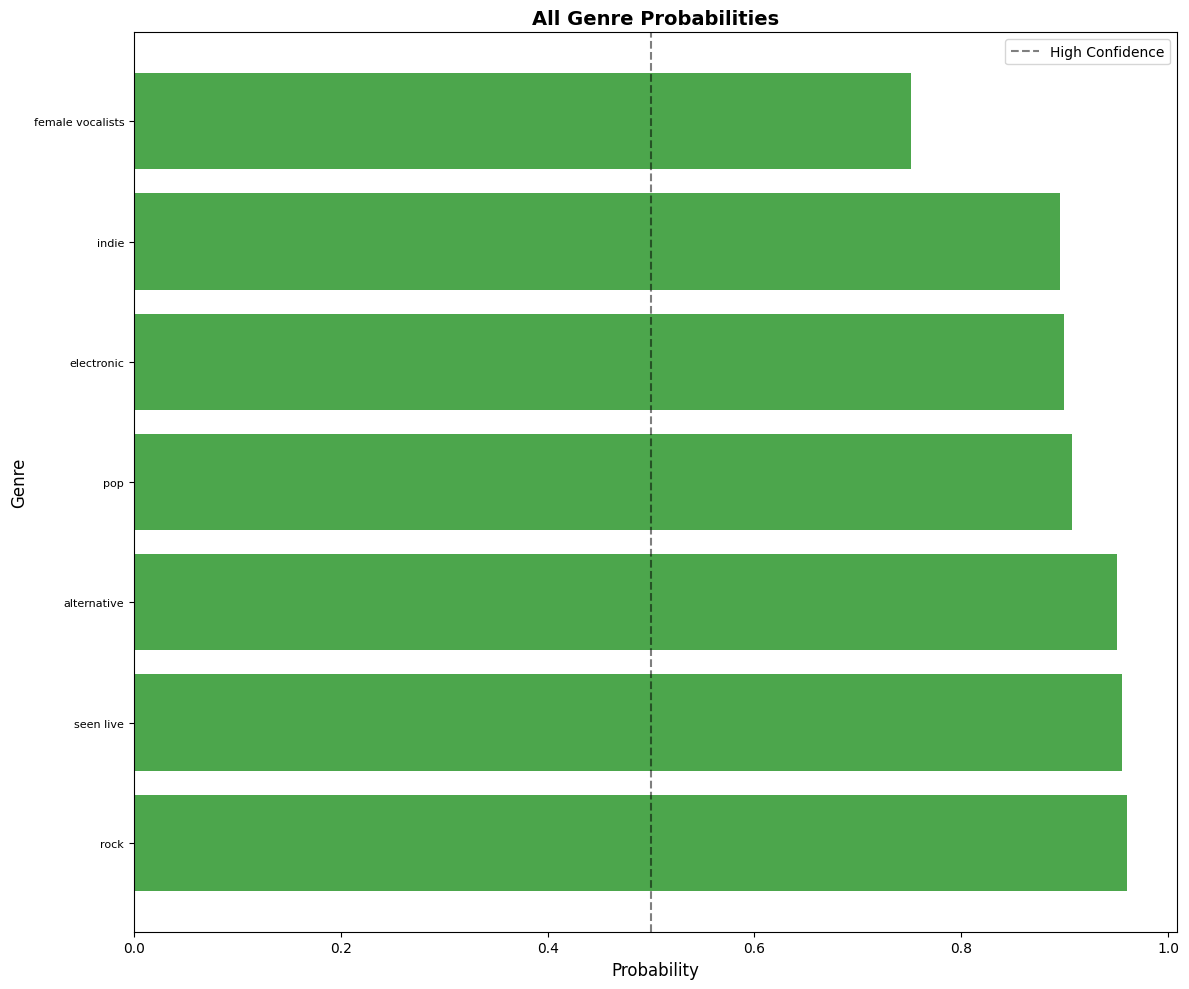

In [10]:
"""
Visualize predictions
"""

# Visualize predictions for first example user
print("Visualizing predictions for:", example_users[0]['name'])
visualizer.plot_top_k_predictions(example_users[0]['data'], k=5)

# Show all genres for the user
print("Showing all genre probabilities...")
visualizer.plot_all_genres(example_users[0]['data'], figsize=(12, 10))

Example: Predicting for a 28-year-old male from Canada


/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]
/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]


User Profile:
  Age: 28
  Gender: m
  Country: Canada
  Registered: 2012
Top-5 Predicted Genres:
  1. rock: 0.978 (97.8%)
  2. seen live: 0.974 (97.4%)
  3. alternative: 0.970 (97.0%)
  4. indie: 0.928 (92.8%)
  5. pop: 0.928 (92.8%)


/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]
/content/AAI-551-Final-Project/src/predictor.py:91: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cat_aligned.loc[0, col] = X_cat.iloc[0][col]


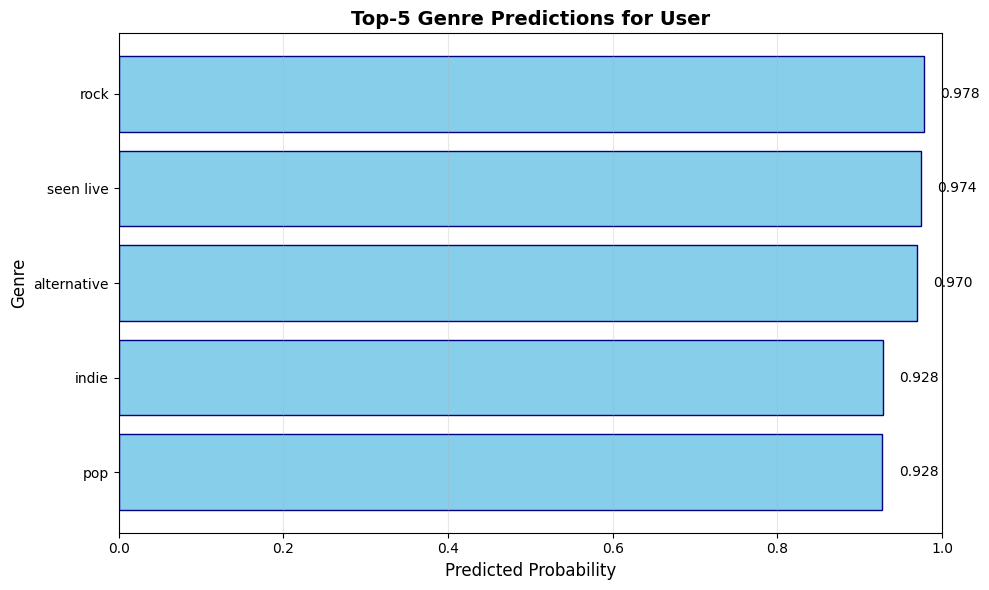

In [11]:
"""
Interactive prediction function for custom users
"""

def predict_for_custom_user(age: int, gender: str, country: str,
                           registered: int, top_k: int = 5):
    """
    Predict genres for a custom user with given demographics.
    """
    user_dict = {
        'age': age,
        'gender': gender,
        'country': country,
        'registered': registered
    }

    predictions = predictor.predict(user_dict, top_k=top_k)

    print(f"User Profile:")
    print(f"  Age: {age}")
    print(f"  Gender: {gender}")
    print(f"  Country: {country}")
    print(f"  Registered: {registered}")
    print(f"Top-{top_k} Predicted Genres:")

    # Use for loop with enumerate
    for i, (genre, prob) in enumerate(predictions, 1):
        print(f"  {i}. {genre}: {prob:.3f} ({prob*100:.1f}%)")

    # Visualize
    visualizer.plot_top_k_predictions(user_dict, k=top_k)

    return predictions

# Example usage
print("Example: Predicting for a 28-year-old male from Canada")
custom_predictions = predict_for_custom_user(
    age=28,
    gender='m',
    country='Canada',
    registered=2012,
    top_k=5
)